In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [3]:
import torch
from src.problems.schrodinger import build_eq_params, sanity_check

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype  = "float64"

eq_params = build_eq_params(
    "box",
    L=1.0, T=0.2, mass=1.0, hbar=1.0, n_level=1
)
print(eq_params)
print("sanity:", sanity_check(eq_params, device=device))


{'example': 'box', 'L': 1.0, 'T': 0.2, 'mass': 1.0, 'hbar': 1.0, 'n_level': 1, 'x_min': 0.0, 'x_max': 1.0, 'omega': 1.0, 'V0': 50.0, 'barrier_width': 0.2, 'x_center': 0.5, 'num_grid': 400}
sanity: {'V_min': 0.0, 'V_max': 0.0, 'psi0_norm': 0.9974968671630001, 'psiT_norm': 0.9974968671630003}


In [4]:
from src.utils.logger import Logging
from src.nn.ClassicalSolver2 import ClassicalSolver2

args = {
    "eq_params": eq_params,
    "device": device,
    "dtype": dtype,
    "epochs": 1500,
    "lr": 1e-3,
    "batch_size": 64,
    "classic_network": [2, 64, 64, 64, 2],
    "print_every": 100,

    # pesos anti-solución-trivial
    "hard_bc": True,
    "w_pde": 1.0,
    "w_bc":  0.1,
    "w_ic":  300.0,
    "w_norm": 1.0,
    "warmup_epochs": 400,
    "ic_grid": True,
    "N_norm": 400,
    "N_val": 400,
}

logger = Logging("./results/models/checkpoints/smoke_schrodinger", "box_Classical")
model = ClassicalSolver2(args, logger, device=torch.device(device))
model.args = args

# dtype coherente
model = model.double() if "64" in dtype else model.float()
model = model.to(torch.device(device))



INFO:src.utils.logger:checkpoint path: self.log_path='./results/models/checkpoints/smoke_schrodinger\\2025-12-15_11-57-02-026119_box_Classical'


In [5]:
from src.trainer.schrodinger_train import train
train(model, N_f=2000, N_b=400, N_0=400)



INFO:src.utils.logger:It: 1, Loss: 3.010e+02, Loss_res: 1.156e-02,  Loss_bcs: 0.000e+00, Loss_ut_ics: 1.000e+00, Loss_norm: 9.991e-01, w_pde: 2.50e-03, L^2_error: 1.011e+00, lr: 1.000e-03, Time: 1.13e-01
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/smoke_schrodinger\2025-12-15_11-57-02-026119_box_Classical\model.pth
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/smoke_schrodinger\2025-12-15_11-57-02-026119_box_Classical\model_weights.pth
INFO:src.utils.logger:It: 100, Loss: 7.112e+00, Loss_res: 2.619e+01,  Loss_bcs: 0.000e+00, Loss_ut_ics: 1.876e-03, Loss_norm: 2.755e-03, w_pde: 2.50e-01, L^2_error: 9.296e-01, lr: 1.000e-03, Time: 9.10e+00
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/smoke_schrodinger\2025-12-15_11-57-02-026119_box_Classical\model.pth
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/smoke_schrodinger\2025-12-15_11-57-02-026119_box_Classical\model_weights.pth
INFO:src.u

L2_rel(T): 0.0025623800150464415


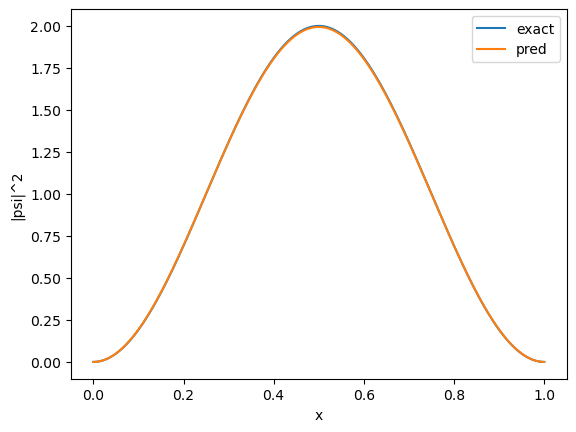

In [6]:
import torch
import matplotlib.pyplot as plt
from src.problems.schrodinger.problem import build_problem

pb = build_problem(eq_params, device=torch.device(device), dtype=torch.float64)

x = torch.linspace(pb["x_min"], pb["x_max"], 400, device=device, dtype=pb["dtype"]).reshape(-1,1)
t = torch.full_like(x, pb["T"])

with torch.no_grad():
    pred = model(torch.cat([t, x], dim=1))
    pr, pi = pred[:,0:1], pred[:,1:2]
    er, ei, _ = pb["exact"](pb["n_level"], t, x)

    l2_abs = torch.sqrt(torch.mean((pr-er)**2 + (pi-ei)**2))
    ref = torch.sqrt(torch.mean(er**2 + ei**2)) + 1e-12
    print("L2_rel(T):", (l2_abs/ref).item())

    prob_pred  = (pr**2 + pi**2).cpu().numpy().flatten()
    prob_exact = (er**2 + ei**2).cpu().numpy().flatten()
    x_cpu = x.cpu().numpy().flatten()

plt.plot(x_cpu, prob_exact, label="exact")
plt.plot(x_cpu, prob_pred,  label="pred")
plt.legend(); plt.xlabel("x"); plt.ylabel("|psi|^2")
plt.show()



In [7]:
import torch

L = eq_params["L"]
x0 = torch.tensor([[0.0]], device=device, dtype=torch.float64)
xL = torch.tensor([[L]],   device=device, dtype=torch.float64)

ts = torch.linspace(0.0, eq_params["T"], 20, device=device, dtype=torch.float64).reshape(-1,1)
x0s = x0.repeat(ts.shape[0], 1)
xLs = xL.repeat(ts.shape[0], 1)

with torch.no_grad():
    psi0 = model(torch.cat([ts, x0s], dim=1))
    psiL = model(torch.cat([ts, xLs], dim=1))

bc0 = torch.sqrt(psi0[:,0]**2 + psi0[:,1]**2).max().item()
bcL = torch.sqrt(psiL[:,0]**2 + psiL[:,1]**2).max().item()

print("max |psi(t,0)|:", bc0)
print("max |psi(t,L)|:", bcL)


max |psi(t,0)|: 0.07263357313001485
max |psi(t,L)|: 0.12945590238739713
